### **1. Identifying Soil Zones**
The statistical characteristics of the four clusters are analyzed here. By looking at the mean values of original soil properties (pH, Organic Carbon, Sand %, etc.), meaningful names can be assigned to these zones.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv("../outputs/soil_clusters_top_3_models.csv")

CLUSTER_MODELS = {
    "K-Means": "cluster_kmeans",
    "Agglomerative": "cluster_agg",
    "GMM": "cluster_gmm"
}

SOIL_FEATURES = [
    "taw",
    "organic_carbon",
    "cec",
    "ph",
    "sand_pct"
]

for model_name, cluster_col in CLUSTER_MODELS.items():

    print("\n" + "="*60)
    print(f"{model_name} - Mean Soil Properties per Cluster")
    print("="*60)

    cluster_summary = (
        df_final
        .groupby(cluster_col)[SOIL_FEATURES]
        .mean()
        .round(2)
    )

    print(cluster_summary)


K-Means - Mean Soil Properties per Cluster
                 taw  organic_carbon    cec    ph  sand_pct
cluster_kmeans                                             
0               8.83            2.91  16.64  5.19     70.33
1               6.90            3.18   9.77  4.86     66.24
2               6.63            3.31  17.20  5.34     78.85
3               7.79            4.11  18.65  4.81     62.29

Agglomerative - Mean Soil Properties per Cluster
              taw  organic_carbon    cec    ph  sand_pct
cluster_agg                                             
0            7.71            4.06  18.65  4.85     63.44
1            8.83            2.89  16.67  5.20     70.84
2            6.89            3.18   9.77  4.86     66.25
3            6.54            3.16  16.55  5.41     80.71

GMM - Mean Soil Properties per Cluster
              taw  organic_carbon    cec    ph  sand_pct
cluster_gmm                                             
0            8.83            2.92  16.66  5.18    

### **2. Visualizing the Differences**

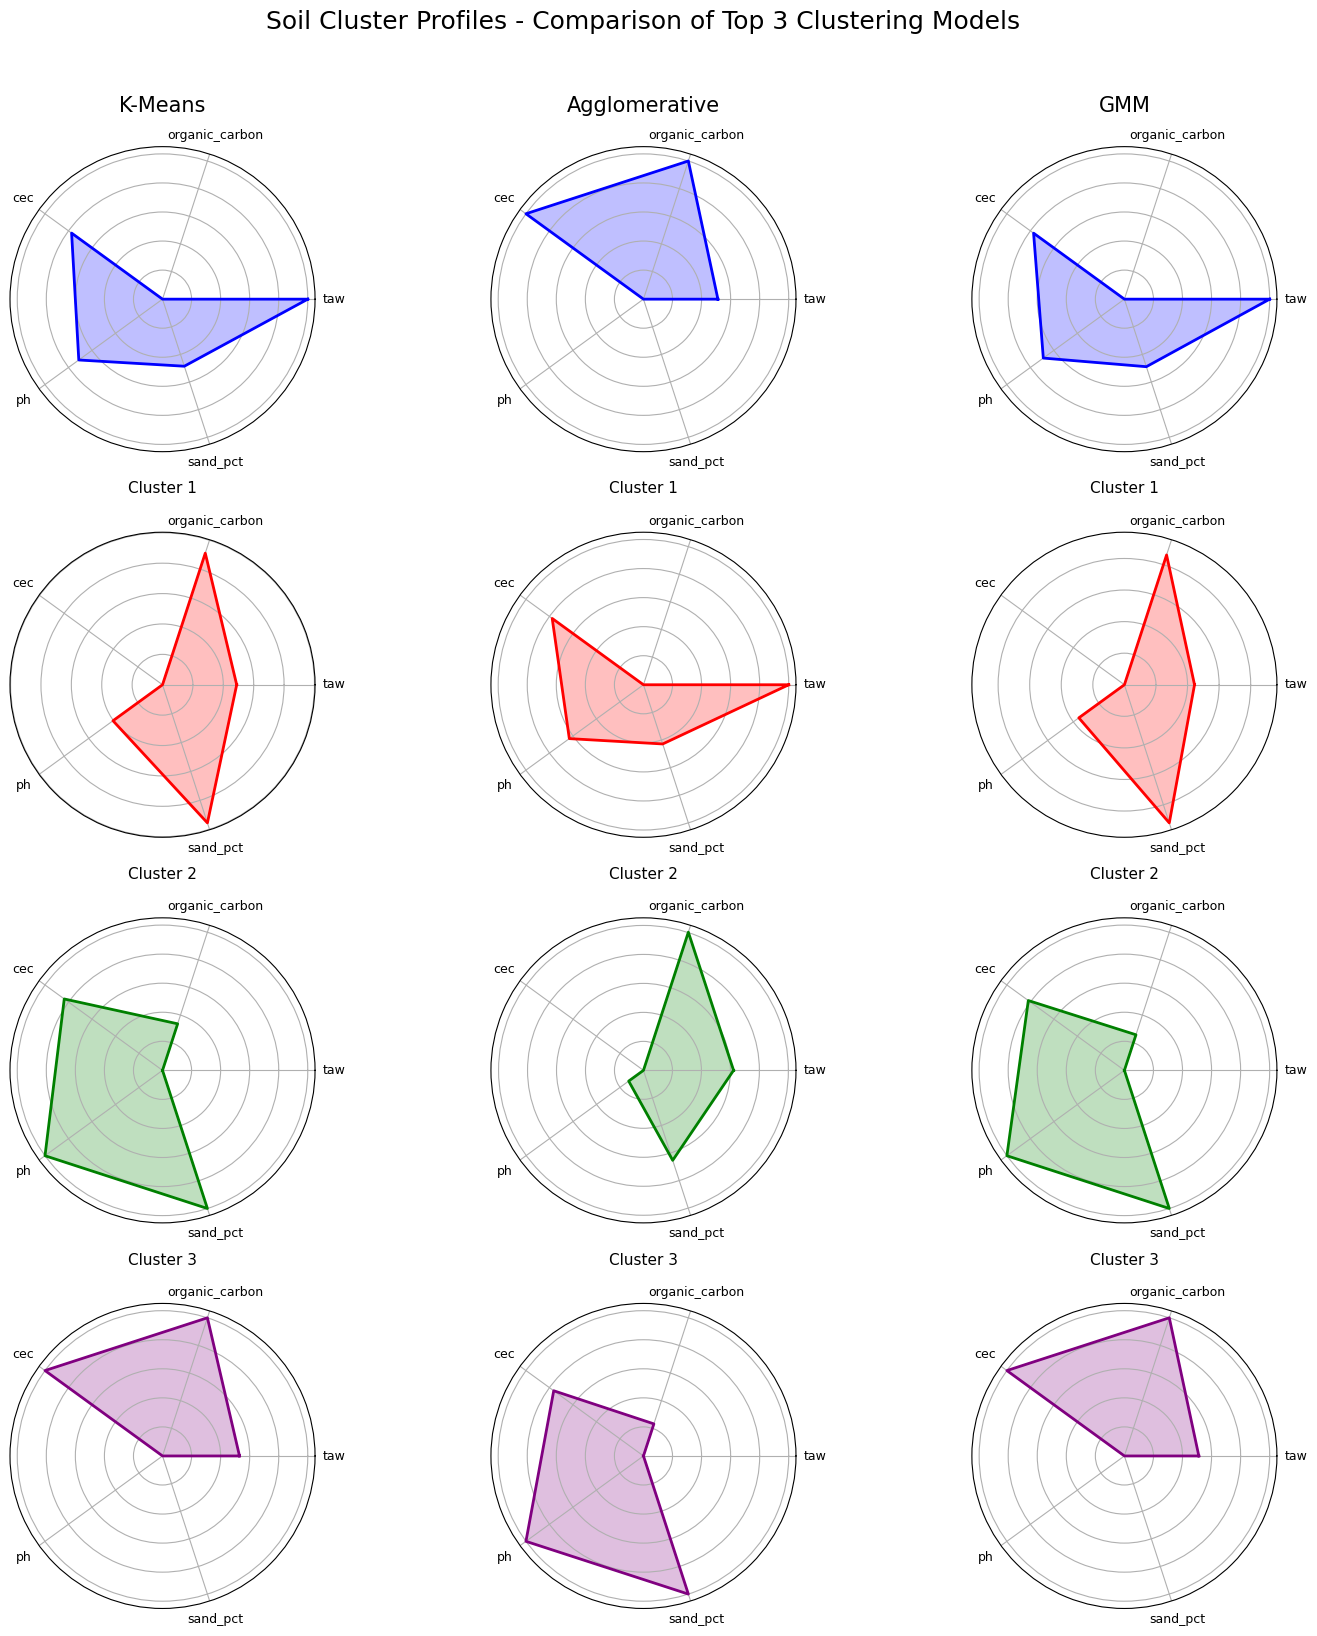

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Radar chart helper
def make_radar_chart(ax, df, cluster_id, color):
    labels = df.columns
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    values = df.loc[cluster_id].tolist()
    values += values[:1]

    ax.fill(angles, values, color=color, alpha=0.25)
    ax.plot(angles, values, color=color, linewidth=2)

    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f"Cluster {cluster_id}", fontsize=11, y=1.1)


# Radar plots
scaler = MinMaxScaler()
colors = ['blue', 'red', 'green', 'purple']

n_models = len(CLUSTER_MODELS)

fig, axes = plt.subplots(
    4, n_models,
    figsize=(5 * n_models, 16),
    subplot_kw=dict(polar=True)
)

for col_idx, (model_name, cluster_col) in enumerate(CLUSTER_MODELS.items()):

    # Mean soil properties
    cluster_summary = (
        df_final
        .groupby(cluster_col)[SOIL_FEATURES]
        .mean()
    )

    # Normalize
    cluster_norm = pd.DataFrame(
        scaler.fit_transform(cluster_summary),
        columns=cluster_summary.columns,
        index=cluster_summary.index
    )

    # Plot each cluster
    for row_idx, cluster_id in enumerate(cluster_norm.index):
        make_radar_chart(
            axes[row_idx, col_idx],
            cluster_norm,
            cluster_id,
            colors[row_idx]
        )

    axes[0, col_idx].set_title(
        model_name,
        fontsize=15,
        pad=25
    )

plt.suptitle(
    "Soil Cluster Profiles - Comparison of Top 3 Clustering Models",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

### **3. Spatial Distribution of Soil Clusters in the Western Province**

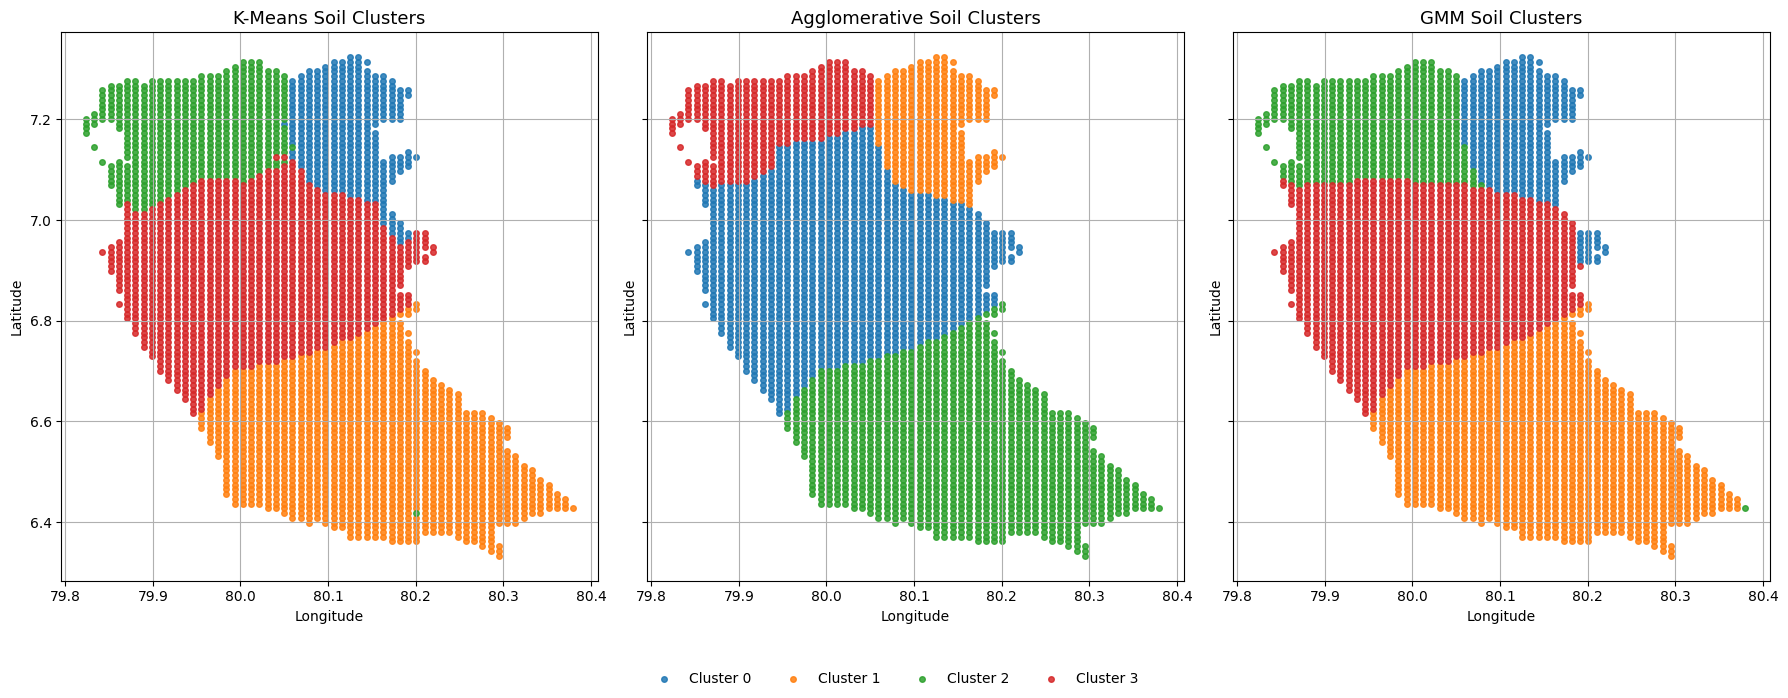

In [8]:
def plot_spatial_clusters_side_by_side(df, cluster_cols, titles):
    fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

    for ax, cluster_col, title in zip(axes, cluster_cols, titles):
        for c in sorted(df[cluster_col].unique()):
            subset = df[df[cluster_col] == c]
            ax.scatter(
                subset["lon"],
                subset["lat"],
                s=16,
                alpha=0.85,
                label=f"Cluster {c}"
            )

        ax.set_title(title, fontsize=13)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True)

    # Single legend for all plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

plot_spatial_clusters_side_by_side(
    df_final,
    cluster_cols=[
        "cluster_kmeans",
        "cluster_agg",
        "cluster_gmm"
    ],
    titles=[
        "K-Means Soil Clusters",
        "Agglomerative Soil Clusters",
        "GMM Soil Clusters"
    ]
)